#Customer Intelligence System

1. Imports & Configuration

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, DBSCAN
from sklearn.neighbors import NearestNeighbors
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.metrics import (classification_report, confusion_matrix,
                             silhouette_score, davies_bouldin_score)
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

RANDOM_STATE = 42
print('Libraries loaded successfully ✅')

Libraries loaded successfully ✅


2. Load Data

In [15]:
# Kaggle input path — attach dataset via Add Input → rohan0301/unsupervised-learning-on-country-data
df = pd.read_csv('Country-data.csv')

print('Shape:', df.shape)
print('\nMissing values:')
print(df.isnull().sum())
df.head(10)

Shape: (167, 10)

Missing values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.440,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.490,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.100,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.400,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.440,76.8,2.13,12200
5,Argentina,14.5,18.9,8.10,16.0,18700,20.900,75.8,2.37,10300
6,Armenia,18.1,20.8,4.40,45.3,6700,7.770,73.3,1.69,3220
7,Australia,4.8,19.8,8.73,20.9,41400,1.160,82.0,1.93,51900
8,Austria,4.3,51.3,11.00,47.8,43200,0.873,80.5,1.44,46900
9,Azerbaijan,39.2,54.3,5.88,20.7,16000,13.800,69.1,1.92,5840


In [16]:
features = ['child_mort', 'exports', 'health', 'imports',
            'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

X = df[features].copy()
X.describe().T.style.background_gradient(cmap='Blues', subset=['mean', 'std', 'max'])

,count,mean,std,min,25%,50%,75%,max
child_mort,167.000000,38.270060,40.328931,2.600000,8.250000,19.300000,62.100000,208.000000
exports,167.000000,41.108976,27.412010,0.109000,23.800000,35.000000,51.350000,200.000000
health,167.000000,6.815689,2.746837,1.810000,4.920000,6.320000,8.600000,17.900000
imports,167.000000,46.890215,24.209589,0.065900,30.200000,43.300000,58.750000,174.000000
income,167.000000,17144.688623,19278.067698,609.000000,3355.000000,9960.000000,22800.000000,125000.000000
inflation,167.000000,7.781832,10.570704,-4.210000,1.810000,5.390000,10.750000,104.000000
life_expec,167.000000,70.555689,8.893172,32.100000,65.300000,73.100000,76.800000,82.800000
total_fer,167.000000,2.947964,1.513848,1.150000,1.795000,2.410000,3.880000,7.490000
gdpp,167.000000,12964.155689,18328.704809,231.000000,1330.000000,4660.000000,14050.000000,105000.000000


3. Exploratory Data Analysis (EDA)

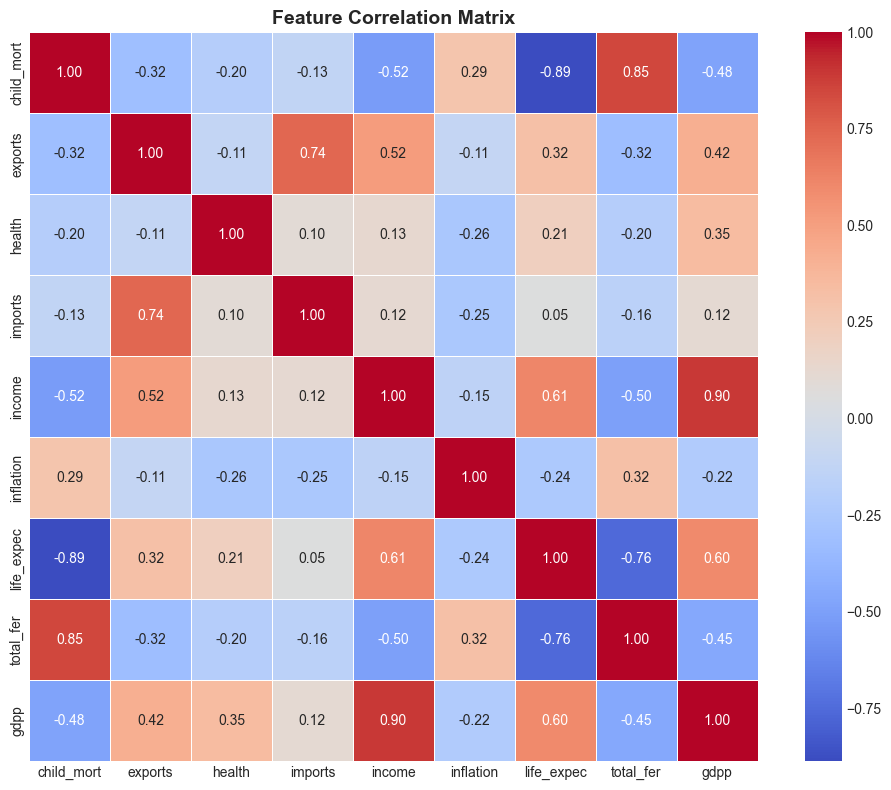

In [17]:
plt.figure(figsize=(10, 8))
sns.heatmap(X.corr(), annot=True, cmap='coolwarm', fmt='.2f',
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=150)
plt.show()
# child_mort & life_expect: strong negative correlation (~-0.88)
# gdpp & income: strong positive correlation (~+0.90)

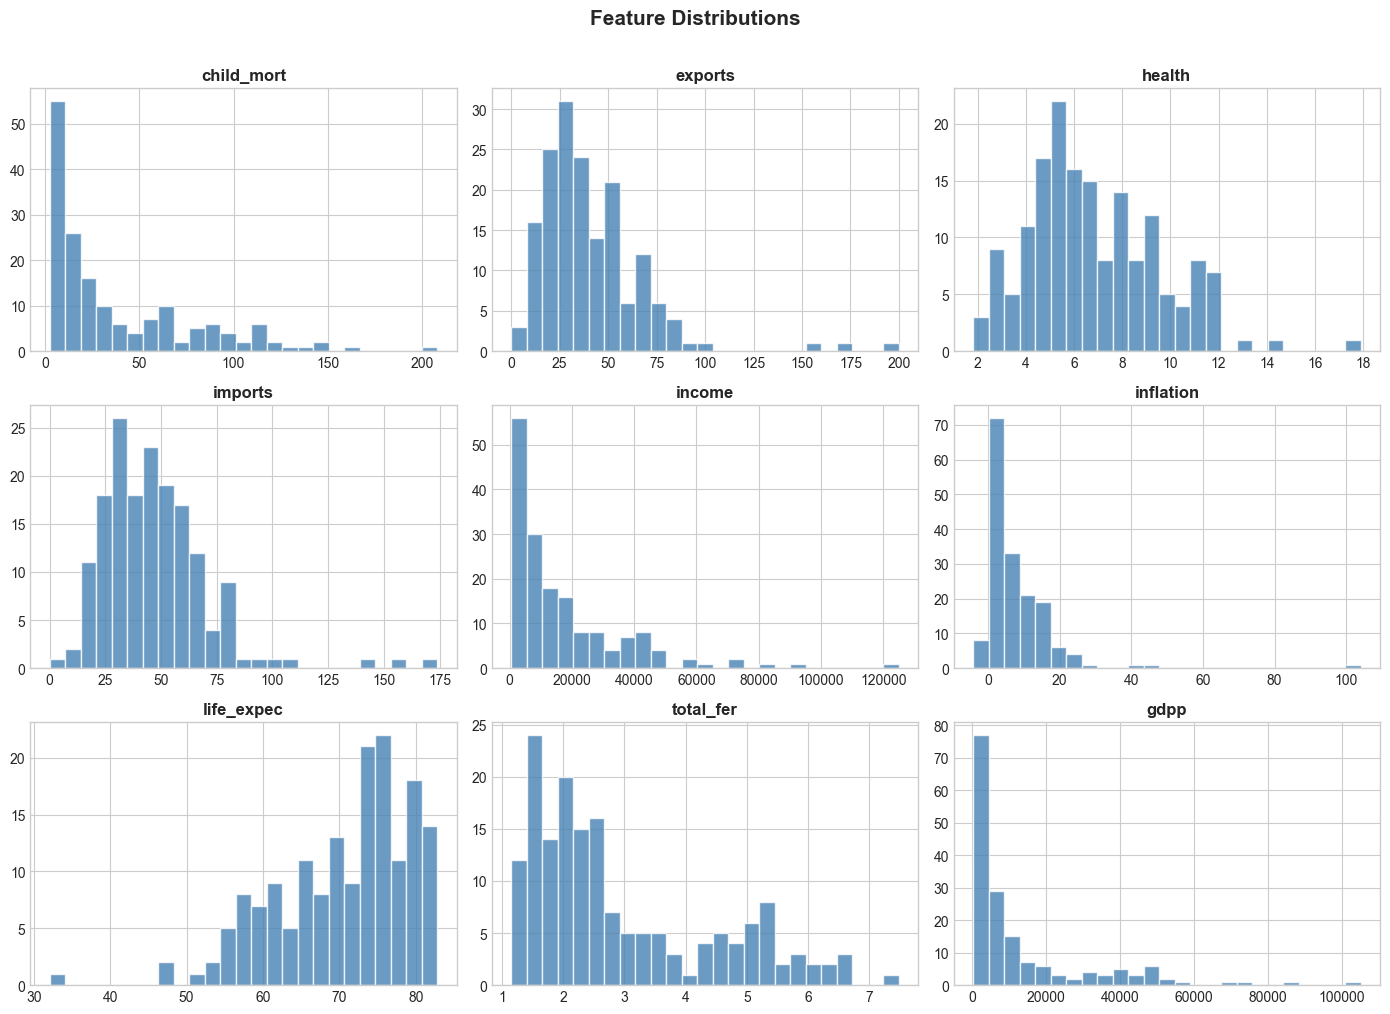

In [18]:
fig, axes = plt.subplots(3, 3, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(features):
    axes[i].hist(X[feat], bins=25, color='steelblue', edgecolor='white', alpha=0.8)
    axes[i].set_title(feat, fontweight='bold')
    axes[i].set_xlabel('')

plt.suptitle('Feature Distributions', fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

4. Preprocessing — StandardScaler + PCA

In [19]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 2D PCA for cluster visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_scaled)
print(f"Explained variance (2 PCs): {pca.explained_variance_ratio_.sum():.2%}")

# PCA retaining 95% variance
pca_full = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_pca_full = pca_full.fit_transform(X_scaled)
print(f"Components to retain 95% variance: {pca_full.n_components_}")

Explained variance (2 PCs): 63.13%
Components to retain 95% variance: 6


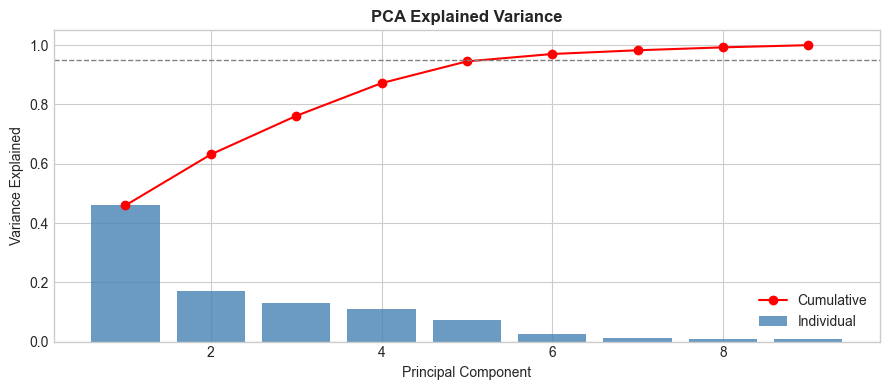

In [20]:
# PCA explained variance per component
pca_all = PCA(random_state=RANDOM_STATE)
pca_all.fit(X_scaled)

plt.figure(figsize=(9, 4))
plt.bar(range(1, len(pca_all.explained_variance_ratio_)+1),
        pca_all.explained_variance_ratio_, color='steelblue', alpha=0.8, label='Individual')
plt.plot(range(1, len(pca_all.explained_variance_ratio_)+1),
         np.cumsum(pca_all.explained_variance_ratio_), 'ro-', label='Cumulative')
plt.axhline(0.95, linestyle='--', color='gray', linewidth=1)
plt.title('PCA Explained Variance', fontweight='bold')
plt.xlabel('Principal Component')
plt.ylabel('Variance Explained')
plt.legend()
plt.tight_layout()
plt.show()

5. K-Means Clustering — Elbow + Silhouette

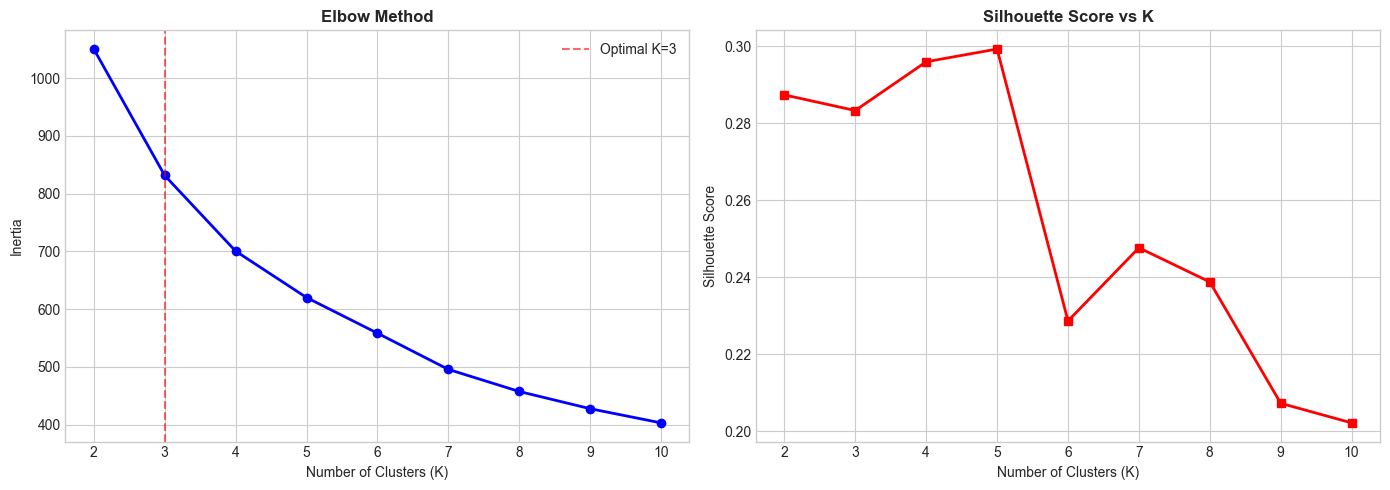

In [21]:
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertias, 'bo-', linewidth=2)
axes[0].set_title('Elbow Method', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')
axes[0].axvline(3, linestyle='--', color='red', alpha=0.6, label='Optimal K=3')
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, 'rs-', linewidth=2)
axes[1].set_title('Silhouette Score vs K', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.tight_layout()
plt.savefig('kmeans_elbow_silhouette.png', dpi=150)
plt.show()

In [22]:
OPTIMAL_K = 3
kmeans = KMeans(n_clusters=OPTIMAL_K, random_state=RANDOM_STATE, n_init=10)
df['kmeans_cluster'] = kmeans.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, df['kmeans_cluster'])
db_score  = davies_bouldin_score(X_scaled, df['kmeans_cluster'])

print(f"K-Means Silhouette Score (K=3) : {sil_score:.4f}  (higher = better)")
print(f"Davies-Bouldin Score           : {db_score:.4f}  (lower  = better)")

K-Means Silhouette Score (K=3) : 0.2833  (higher = better)
Davies-Bouldin Score           : 1.2769  (lower  = better)


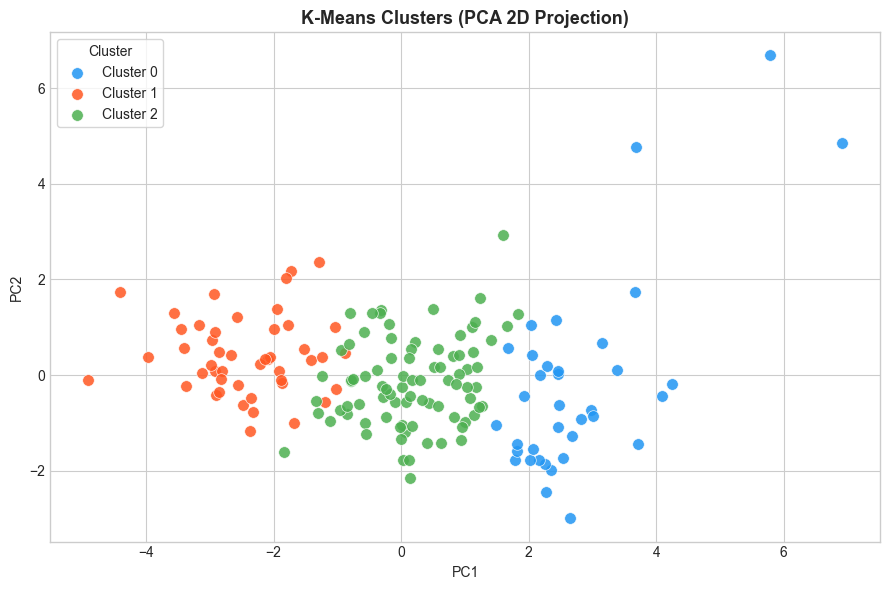

In [23]:
colors = ['#2196F3', '#FF5722', '#4CAF50']

plt.figure(figsize=(9, 6))
for c in range(OPTIMAL_K):
    mask = df['kmeans_cluster'] == c
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1],
                c=colors[c], label=f'Cluster {c}', s=70, alpha=0.85, edgecolors='white', linewidths=0.5)

plt.title('K-Means Clusters (PCA 2D Projection)', fontsize=13, fontweight='bold')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.legend(title='Cluster', frameon=True)
plt.tight_layout()
plt.savefig('kmeans_clusters_pca.png', dpi=150)
plt.show()

6. DBSCAN — Density-Based Clustering

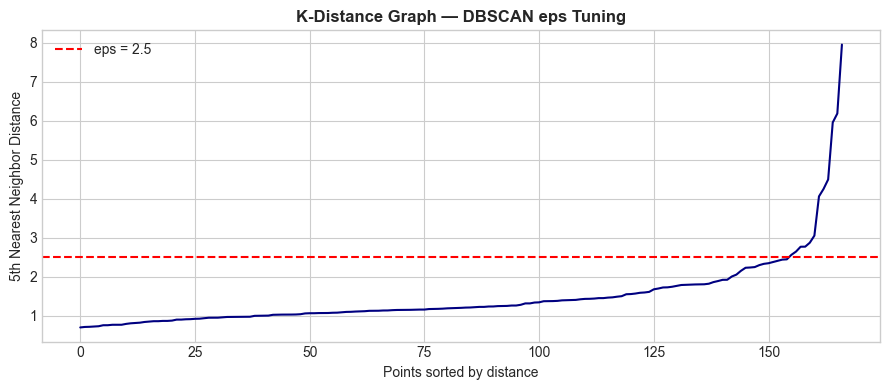

In [24]:
# Tune eps using K-distance graph
nbrs = NearestNeighbors(n_neighbors=5).fit(X_scaled)
distances, _ = nbrs.kneighbors(X_scaled)
k_distances = np.sort(distances[:, -1])

plt.figure(figsize=(9, 4))
plt.plot(k_distances, color='navy')
plt.title('K-Distance Graph — DBSCAN eps Tuning', fontweight='bold')
plt.xlabel('Points sorted by distance')
plt.ylabel('5th Nearest Neighbor Distance')
plt.axhline(2.5, linestyle='--', color='red', label='eps = 2.5')
plt.legend()
plt.tight_layout()
plt.savefig('dbscan_kdistance.png', dpi=150)
plt.show()

In [25]:
dbscan = DBSCAN(eps=2.5, min_samples=5)
df['dbscan_cluster'] = dbscan.fit_predict(X_scaled)

n_clusters_db = len(set(df['dbscan_cluster'])) - (1 if -1 in df['dbscan_cluster'].values else 0)
n_noise       = (df['dbscan_cluster'] == -1).sum()

print(f"DBSCAN: {n_clusters_db} cluster(s) found, {n_noise} noise/outlier points")
print('\nCluster value counts:')
print(df['dbscan_cluster'].value_counts().sort_index())
print('\nNoise countries (anomalous economies):')
print(df[df['dbscan_cluster'] == -1]['country'].tolist())

DBSCAN: 1 cluster(s) found, 6 noise/outlier points

Cluster value counts:
dbscan_cluster
-1      6
 0    161
Name: count, dtype: int64

Noise countries (anomalous economies):
['Haiti', 'Luxembourg', 'Malta', 'Nigeria', 'Qatar', 'Singapore']


7. Cluster Profiling & Segment Labeling

In [26]:
cluster_profile = df.groupby('kmeans_cluster')[features].mean().round(2)
print('Cluster Profiles (Mean Values):')
cluster_profile.style.background_gradient(cmap='RdYlGn', axis=0)

Cluster Profiles (Mean Values):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
kmeans_cluster,,,,,,,,,
0,5.000000,58.740000,8.810000,51.490000,45672.220000,2.670000,80.130000,1.750000,42494.440000
1,92.960000,29.150000,6.390000,42.320000,3942.400000,12.020000,59.190000,5.010000,1922.380000
2,21.930000,40.240000,6.200000,47.470000,12305.600000,7.600000,72.810000,2.310000,6486.450000


In [27]:
# Auto-label clusters based on GDP per capita ranking
cluster_labels = {
    cluster_profile['gdpp'].idxmax(): 'Developed',
    cluster_profile['gdpp'].idxmin(): 'Underdeveloped',
}
middle = [c for c in range(OPTIMAL_K) if c not in cluster_labels][0]
cluster_labels[middle] = 'Developing'

df['segment'] = df['kmeans_cluster'].map(cluster_labels)

print('Segment Distribution:')
print(df['segment'].value_counts())

# Radar / bar chart per segment
seg_summary = df.groupby('segment')[features].mean().round(2).sort_values('gdpp')
seg_summary.style.background_gradient(cmap='Blues', subset=['gdpp', 'income']) \
                 .background_gradient(cmap='Reds',  subset=['child_mort', 'total_fer'])

Segment Distribution:
segment
Developing        84
Underdeveloped    47
Developed         36
Name: count, dtype: int64


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
segment,,,,,,,,,
Underdeveloped,92.960000,29.150000,6.390000,42.320000,3942.400000,12.020000,59.190000,5.010000,1922.380000
Developing,21.930000,40.240000,6.200000,47.470000,12305.600000,7.600000,72.810000,2.310000,6486.450000
Developed,5.000000,58.740000,8.810000,51.490000,45672.220000,2.670000,80.130000,1.750000,42494.440000


8. Ensemble Classification — Random Forest + XGBoost

In [28]:
label_map = {'Developed': 2, 'Developing': 1, 'Underdeveloped': 0}
y = df['segment'].map(label_map)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Train: {X_train.shape}, Test: {X_test.shape}')
print('Class distribution (train):', dict(zip(*np.unique(y_train, return_counts=True))))

Train: (133, 9), Test: (34, 9)
Class distribution (train): {0: 37, 1: 67, 2: 29}


In [29]:
rf_params = {
    'n_estimators':     [100, 200],
    'max_depth':        [None, 5, 10],
    'min_samples_split':[2, 5]
}

rf = GridSearchCV(
    RandomForestClassifier(random_state=RANDOM_STATE),
    rf_params, cv=5, scoring='f1_weighted', n_jobs=-1
)
rf.fit(X_train, y_train)
best_rf  = rf.best_estimator_
rf_preds = best_rf.predict(X_test)

print('=== Random Forest ===')
print(f'Best Params: {rf.best_params_}')
print(classification_report(y_test, rf_preds,
      target_names=['Underdeveloped', 'Developing', 'Developed']))

=== Random Forest ===
Best Params: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}
                precision    recall  f1-score   support

Underdeveloped       1.00      1.00      1.00        10
    Developing       1.00      1.00      1.00        17
     Developed       1.00      1.00      1.00         7

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



In [30]:
xgb_params = {
    'n_estimators': [100, 200],
    'max_depth':    [3, 6],
    'learning_rate':[0.05, 0.1],
    'subsample':    [0.8, 1.0]
}

xgb = GridSearchCV(
    XGBClassifier(random_state=RANDOM_STATE, eval_metric='mlogloss'),
    xgb_params, cv=5, scoring='f1_weighted', n_jobs=-1
)
xgb.fit(X_train, y_train)
best_xgb  = xgb.best_estimator_
xgb_preds = best_xgb.predict(X_test)

print('=== XGBoost ===')
print(f'Best Params: {xgb.best_params_}')
print(classification_report(y_test, xgb_preds,
      target_names=['Underdeveloped', 'Developing', 'Developed']))

=== XGBoost ===
Best Params: {'learning_rate': 0.05, 'max_depth': 3, 'n_estimators': 100, 'subsample': 0.8}
                precision    recall  f1-score   support

Underdeveloped       1.00      1.00      1.00        10
    Developing       1.00      1.00      1.00        17
     Developed       1.00      1.00      1.00         7

      accuracy                           1.00        34
     macro avg       1.00      1.00      1.00        34
  weighted avg       1.00      1.00      1.00        34



In [31]:
# 10-Fold Cross Validation
rf_cv  = cross_val_score(best_rf,  X_scaled, y, cv=10, scoring='f1_weighted')
xgb_cv = cross_val_score(best_xgb, X_scaled, y, cv=10, scoring='f1_weighted')

cv_df = pd.DataFrame({
    'Model':     ['Random Forest', 'XGBoost'],
    'CV F1 Mean':[round(rf_cv.mean(), 4), round(xgb_cv.mean(), 4)],
    'CV F1 Std': [round(rf_cv.std(),  4), round(xgb_cv.std(),  4)]
})
print('10-Fold Cross-Validation Results:')
cv_df

10-Fold Cross-Validation Results:


,Model,CV F1 Mean,CV F1 Std
0,Random Forest,0.9635,0.0402
1,XGBoost,0.9637,0.0396


9. Feature Importance (XGBoost)

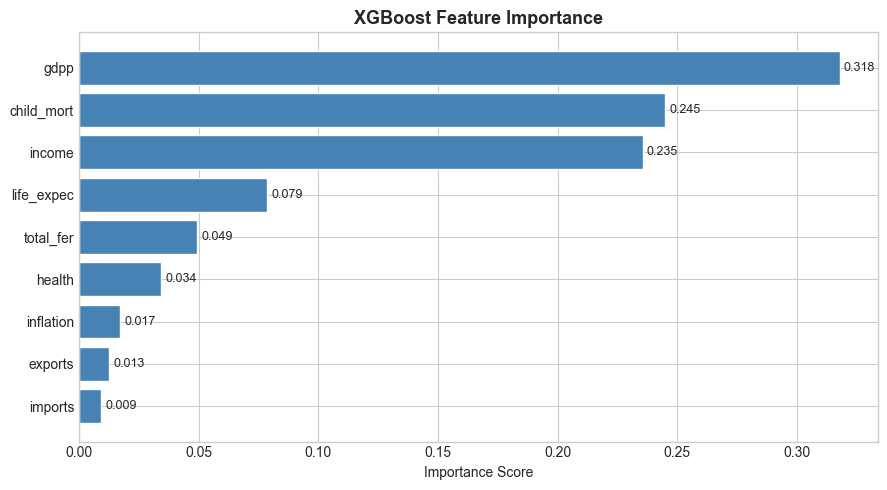

In [32]:
importances = pd.Series(best_xgb.feature_importances_, index=features).sort_values()

plt.figure(figsize=(9, 5))
bars = plt.barh(importances.index, importances.values, color='steelblue', edgecolor='white')
plt.bar_label(bars, fmt='%.3f', padding=3, fontsize=9)
plt.title('XGBoost Feature Importance', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()

10. Confusion Matrix — XGBoost

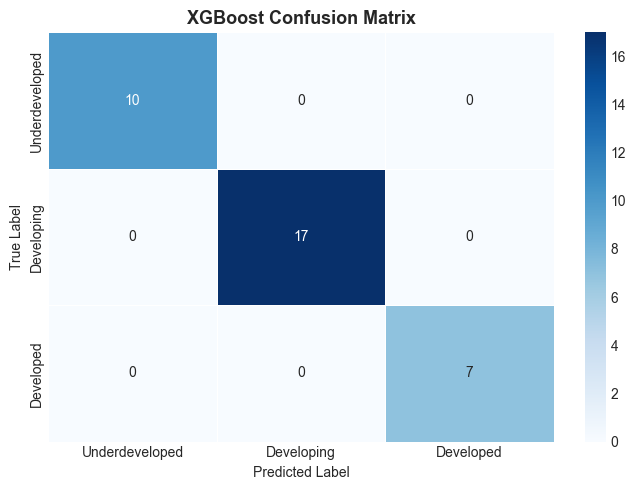

In [33]:
cm = confusion_matrix(y_test, xgb_preds)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Underdeveloped', 'Developing', 'Developed'],
            yticklabels=['Underdeveloped', 'Developing', 'Developed'],
            linewidths=0.5)
plt.title('XGBoost Confusion Matrix', fontsize=13, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()

11. Actionable Insights Report

In [35]:
print('\n' + '='*60)
print('   ACTIONABLE CUSTOMER INTELLIGENCE INSIGHTS')
print('='*60)

for segment in ['Underdeveloped', 'Developing', 'Developed']:
    subset = df[df['segment'] == segment]
    top5   = subset.nsmallest(5, 'gdpp')['country'].tolist()
    print(f'\n[{segment.upper()}] — {len(subset)} countries')
    print(f'  Avg GDP/capita     : ${subset["gdpp"].mean():,.0f}')
    print(f'  Avg Life Expectancy: {subset["life_expec"].mean():.1f} yrs')
    print(f'  Avg Child Mortality: {subset["child_mort"].mean():.1f}/1000')
    print(f'  Avg Fertility Rate : {subset["total_fer"].mean():.2f}')
    print(f'  Priority countries : {top5}')


   ACTIONABLE CUSTOMER INTELLIGENCE INSIGHTS

[UNDERDEVELOPED] — 47 countries
  Avg GDP/capita     : $1,922
  Avg Life Expectancy: 59.2 yrs
  Avg Child Mortality: 93.0/1000
  Avg Fertility Rate : 5.01
  Priority countries : ['Burundi', 'Liberia', 'Congo, Dem. Rep.', 'Niger', 'Sierra Leone']

[DEVELOPING] — 84 countries
  Avg GDP/capita     : $6,486
  Avg Life Expectancy: 72.8 yrs
  Avg Child Mortality: 21.9/1000
  Avg Fertility Rate : 2.31
  Priority countries : ['Nepal', 'Tajikistan', 'Bangladesh', 'Cambodia', 'Kyrgyz Republic']

[DEVELOPED] — 36 countries
  Avg GDP/capita     : $42,494
  Avg Life Expectancy: 80.1 yrs
  Avg Child Mortality: 5.0/1000
  Avg Fertility Rate : 1.75
  Priority countries : ['Slovak Republic', 'Czech Republic', 'Bahrain', 'Malta', 'South Korea']


In [37]:
# Final labelled output
output_df = df[['country', 'segment', 'kmeans_cluster', 'gdpp', 'life_expec', 'child_mort', 'total_fer']]
output_df = output_df.sort_values('gdpp')
output_df.to_csv('country_segments.csv', index=False)
print('Saved country_segments.csv ✅')
output_df.head(15)

Saved country_segments.csv ✅


,country,segment,kmeans_cluster,gdpp,life_expec,child_mort,total_fer
26,Burundi,Underdeveloped,1,231,57.7,93.6,6.26
88,Liberia,Underdeveloped,1,327,60.8,89.3,5.02
37,"Congo, Dem. Rep.",Underdeveloped,1,334,57.5,116.0,6.54
112,Niger,Underdeveloped,1,348,58.8,123.0,7.49
132,Sierra Leone,Underdeveloped,1,399,55.0,160.0,5.20
93,Madagascar,Underdeveloped,1,413,60.8,62.2,4.60
106,Mozambique,Underdeveloped,1,419,54.5,101.0,5.56
31,Central African Republic,Underdeveloped,1,446,47.5,149.0,5.21
94,Malawi,Underdeveloped,1,459,53.1,90.5,5.31
50,Eritrea,Underdeveloped,1,482,61.7,55.2,4.61
